# Q2: The Midnight Episode
### EE200 Course Project
**Name:** Kartik Agrawal

## (a) Reading the Signal
**Total Duration:** $T = 5000 / 250 = 20$ s.

**Heart Rate:** $60 / 0.8 = 75$ bpm.

**Samples per beat:** $0.8 \times 250 = 200$ samples.

**Fundamental Frequency:** $f_0 = 1 / 0.8 = 1.25$ Hz.

## (b) Frequency Domain
- The spectrum consists of discrete harmonic spikes at multiples of 1.25 Hz.
- The QRS complex contributes to high frequencies.
- If HR doubles to 150 bpm, $f_0$ becomes 2.5 Hz and harmonic spacing doubles.

## (c) Windowing
- A 200-sample window captures exactly one beat.
- An 80-sample window truncates physiological features.
- A 600-sample window averages multiple beats.

## (d) Correlation
- $\rho(m) \in [-1, 1]$.
- Normalization ensures scale invariance against amplitude variations.
- An inverted beat yields $\rho \approx -1$.

## (e) Onset & Spectrogram
- $\rho < \tau$ flags onset. Too high = false alarms, too low = missed events.
- Healthy region shows clear horizontal bands; arrhythmia shows chaotic noise.
- Correlation is precise; spectrograms suffer from time-smearing.

## (f) Sampling & Aliasing
- Nyquist minimum rate is $f_s \ge 2 \times 40 = 80$ Hz.
- Sampling at 50 Hz causes aliasing, distorting QRS spikes.
- Fix requires an analog anti-aliasing low-pass filter ($f_c < 25$ Hz).

## (g) Arrhythmia Detector implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

ecg = np.load('EE200_course_project_data_2026/Q2_data/patient_ecg.npy')
tmpl = np.load('EE200_course_project_data_2026/Q2_data/template.npy')

def get_onset(ecg, tmpl, thr=0.5):
    L, N = len(tmpl), len(ecg)
    nt = np.linalg.norm(tmpl)
    for m in range(0, N - L + 1, L):
        seg = ecg[m : m+L]
        ns = np.linalg.norm(seg)
        if ns > 0:
            rho = np.dot(tmpl, seg) / (nt * ns)
            if rho < thr: return m
    return -1

onset = get_onset(ecg, tmpl, 0.5)
print(f'Onset found at sample {onset} (t = {onset/250:.2f} s)')

Onset found at sample 2400 (t = 9.60 s)


## (h) Spectrogram generation

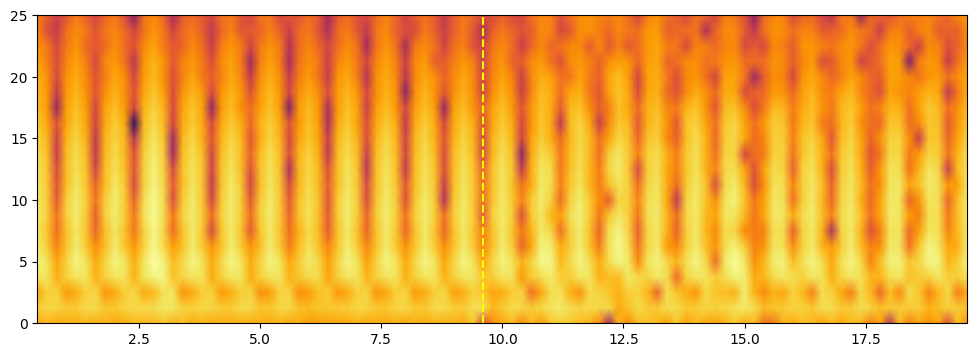

In [2]:
from scipy.signal import spectrogram

f, t, Sxx = spectrogram(ecg, fs=250, nperseg=200, noverlap=150, window='hann')
plt.figure(figsize=(12, 4))
plt.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-12), shading='gouraud', cmap='inferno')
plt.ylim(0, 25)
if onset != -1: plt.axvline(onset/250, color='yellow', linestyle='--')
plt.show()